In [8]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [9]:
def f(x):
    return 3*x**2 - 4*x + 5

In [10]:
f(3.0)

20.0

In [11]:
xs=np.arange(-5,5,0.25)

In [12]:
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [13]:
ys=f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

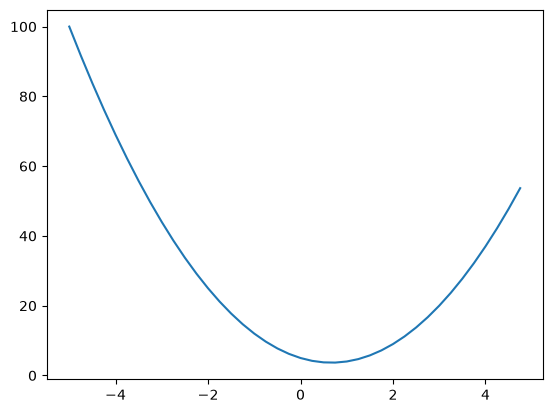

In [14]:
plt.plot(xs, ys)

In [15]:
h = 0.001
x = 3.0
f(x+h)-f(x)
(f(x+h)-f(x))/h

14.00300000000243

In [16]:
a=2.0
b=-3.0
c=10.0
d=a*b+c
print(d)

4.0


In [17]:
h=0.0001

#inputs
a=2.0
b=-3.0
c=10.0

d1 = a*b+c
a += h
d2 = a*b+c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [18]:
h=0.0001

#inputs
a=2.0
b=-3.0
c=10.0

d1 = a*b+c
b += h
d2 = a*b+c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 4.0002
slope 2.0000000000042206


In [19]:
h=0.1

#inputs
a=2.0
b=-3.0
c=10.0

d1 = a*b+c
c += h
d2 = a*b+c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 4.1
slope 0.9999999999999964


In [42]:
class Value:

  def __init__(self, data, children = (), _op='', label = ''):
    self.data = data
    self.grad = 0
    self._prev = set(children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value({self.data})"

  def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
  def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

a=Value(2.0, label = 'a')
b=Value(-3.0, label = 'b')
c=Value(10.0, label = 'c')
e = a*b; e.label = 'e'
d=e+c; d.label = 'd'
f = Value(-2.0, label = 'f')
L = d * f; L.label = 'L'
print(d._prev)
print(d._op)

{Value(-6.0), Value(10.0)}
+


In [31]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):

    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #LR = left to right

    nodes, edges = trace(root)
    for n in  nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape = 'record')
        if n._op:
            dot.node(name=uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op) 

    return dot

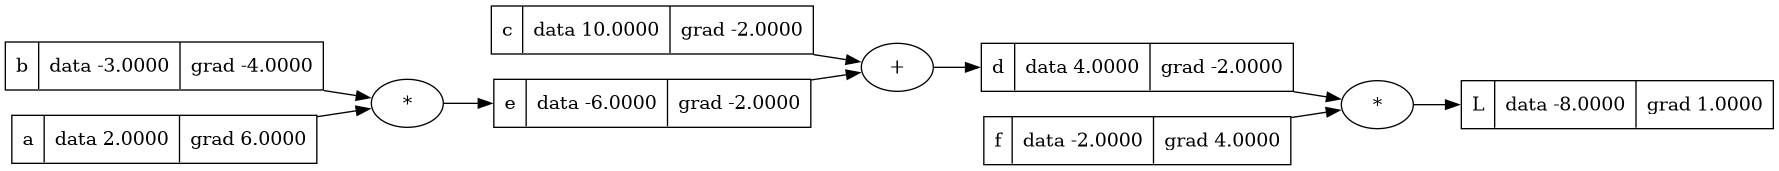

'micrograd_graph.png'

In [47]:
from IPython.display import Image, display
L.grad=1
d.grad=-2
f.grad=4
c.grad=-2
e.grad=-2
a.grad=6
b.grad=-4
dot = draw_dot(L)
display(Image(data=dot.pipe(format="png")))
dot.render("micrograd_graph", format="png", cleanup=True)